In [62]:
import json
from pathlib import Path
import csv
import numpy as np

import sys


import matplotlib.pyplot as plt

from skimage.draw import polygon as draw_polygon
from skimage.io import imsave

try:
    from scipy.interpolate import splprep, splev
    _has_scipy = True
except Exception:
    _has_scipy = False

from PIL import Image

from sam2.addons import Sam2Tiler

from tqdm.auto import tqdm

import h5py

In [2]:
in_path = Path("/Volumes/warm_SD/data/160/00_series/00/160_00_01_50x_patches")
out_dir = Path("/Volumes/warm_SD/data/160/00_series/00/160_00_01_50x_patches")

In [3]:
json_files = []
if in_path.is_dir():
    json_files = sorted(in_path.glob("*.json"))
elif in_path.suffix.lower() == ".json":
    json_files = [in_path]
else:
    raise SystemExit("Input must be a LabelMe JSON file or a folder of JSONs.")

if not json_files:
    raise SystemExit("No LabelMe JSON files found.")
else:
    print(f"Found {len(json_files)} *.json files")

Found 90 *.json files


In [4]:
def chaikin_smooth(points, iterations=2, closed=True):
    """
    Chaikin corner-cutting. points: (N,2) array.
    """
    pts = np.asarray(points, dtype=float)
    if closed:
        pts = np.concatenate([pts, pts[:1]], axis=0)
    for _ in range(iterations):
        Q = 0.75 * pts[:-1] + 0.25 * pts[1:]
        R = 0.25 * pts[:-1] + 0.75 * pts[1:]
        pts = np.empty((Q.shape[0] + R.shape[0], 2))
        pts[0::2] = Q
        pts[1::2] = R
        if closed:
            pts = np.concatenate([pts, pts[:1]], axis=0)
    if closed:
        return pts[:-1]
    return pts


def bspline_smooth(points, k=3, num=200, closed=True, per=True, s=0.0):
    """
    B-spline smoothing using SciPy. per=True enforces periodicity (nice for closed polygons).
    s is smoothing factor (0 = interpolating spline).
    """
    if not _has_scipy:
        raise RuntimeError("SciPy not available; install scipy or use chaikin smoothing.")
    pts = np.asarray(points, dtype=float)
    if closed:
        if not np.allclose(pts[0], pts[-1]):
            pts = np.vstack([pts, pts[0]])
    x, y = pts[:, 0], pts[:, 1]
    t = np.linspace(0, 1, len(pts))
    # Fit parametric spline
    tck, _ = splprep([x, y], u=t, s=s, per=per, k=min(k, len(pts)-1))
    unew = np.linspace(0, 1, num=num)
    out = np.vstack(splev(unew, tck)).T
    return out


def rasterize_polygon(points, height, width):
    """Return row/col indices for filled polygon inside bounds."""
    pts = np.asarray(points, dtype=float)
    rr, cc = draw_polygon(pts[:, 1], pts[:, 0], (height, width))
    return rr, cc


def to_uint_safe(max_id):
    """Pick a safe dtype for instance maps based on max instance id."""
    if max_id < 256:
        return np.uint8
    if max_id < 65536:
        return np.uint16
    return np.uint32


def convert_labelme_json(
    json_path: Path,
    out_dir: Path,
    smooth_method: str = "none",   # 'none' | 'chaikin' | 'bspline'
    smooth_iters: int = 2,         # for chaikin
    bspline_points: int = 200,     # number of points in bspline curve
    bspline_s: float = 0.0,        # smoothing factor for bspline
    include_labels: set | None = None,  # filter by label if desired
):
    data = json.loads(json_path.read_text(encoding="utf-8"))

    H = data.get("imageHeight")
    W = data.get("imageWidth")
    inst = len(data.get("shapes", []))

    if H is None or W is None:
        raise ValueError(f"{json_path.name}: Missing imageHeight/imageWidth in JSON.")

    inst_map = np.zeros((H, W), dtype=np.uint32)  # large enough, cast later
    
    sam2 = []
    instances = []  # list of (id, label)

    instance_id = 0
    for shp in data.get("shapes", []):
        if shp.get("shape_type", "polygon") != "polygon":
            continue  # skip non-polygons (extend here if needed)
        sam2_dict = {}

        label = shp.get("label", "object")
        if include_labels is not None and label not in include_labels:
            continue

        pts = np.asarray(shp.get("points", []), dtype=float)
        if pts.shape[0] < 3:
            continue  # need at least a triangle

        # Smooth if requested
        if smooth_method == "chaikin":
            pts = chaikin_smooth(pts, iterations=smooth_iters, closed=True)
        elif smooth_method == "bspline":
            pts = bspline_smooth(pts, k=3, num=bspline_points, closed=True, per=True, s=bspline_s)
        # else: no smoothing

        # Clip to image bounds before rasterization (helps robustness)
        pts[:, 0] = np.clip(pts[:, 0], 0, W - 1)
        pts[:, 1] = np.clip(pts[:, 1], 0, H - 1)

        rr, cc = rasterize_polygon(pts, H, W)

        instance_id += 1
        inst_map[rr, cc] = instance_id  # later shapes overwrite earlier ones
        inst = np.zeros((H, W), dtype=bool)
        inst[rr, cc] = True

        # --- compute bounding box ---
        ymin, ymax = int(rr.min()), int(rr.max())
        xmin, xmax = int(cc.min()), int(cc.max())
        bbox = [xmin, ymin, xmax - xmin, ymax - ymin]  # [x0, y0, w, h] convention

        # --- fill dict ---
        sam2_dict = {}
        sam2_dict["segmentation"] = inst
        sam2_dict["bbox"] = bbox
        sam2.append(sam2_dict)
        instances.append((instance_id, label))

    # Cast to compact dtype
    inst_map = inst_map.astype(to_uint_safe(int(inst_map.max())))

    # Save outputs
    stem = json_path.stem
    out_dir.mkdir(parents=True, exist_ok=True)

    np.save(out_dir / f"{stem}_instmap.npy", inst_map)
    # PNG (be mindful of dtype limits)
    imsave(out_dir / f"{stem}_instance.png", inst_map)

    # CSV mapping
    with open(out_dir / f"{stem}_instances.csv", "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["instance_id", "label"])
        writer.writerows(instances)

    return inst_map, instances, sam2

In [5]:
per_tile_sam2 = []

for j in tqdm(json_files[:], desc="Processing files"):


    inst_map, instances,sam2 = convert_labelme_json(
            j,
            out_dir=out_dir,
            smooth_method='chaikin',
            smooth_iters=6,
            # bspline_points=args.bspline_points,
            # bspline_s=args.bspline_s,
            # include_labels=include_labels,
        )
    per_tile_sam2.append(sam2)
    

Processing files:   0%|          | 0/90 [00:00<?, ?it/s]

/Users/christian/Projects/segment-anything-2/.venv/lib/python3.11/site-packages/skimage/_shared/utils.py:328: UserWarning: /Volumes/warm_SD/data/160/00_series/00/160_00_01_50x_patches/patch_000029_instance.png is a low contrast image
  return func(*args, **kwargs)
/Users/christian/Projects/segment-anything-2/.venv/lib/python3.11/site-packages/skimage/_shared/utils.py:328: UserWarning: /Volumes/warm_SD/data/160/00_series/00/160_00_01_50x_patches/patch_000059_instance.png is a low contrast image
  return func(*args, **kwargs)
/Users/christian/Projects/segment-anything-2/.venv/lib/python3.11/site-packages/skimage/_shared/utils.py:328: UserWarning: /Volumes/warm_SD/data/160/00_series/00/160_00_01_50x_patches/patch_000060_instance.png is a low contrast image
  return func(*args, **kwargs)
/Users/christian/Projects/segment-anything-2/.venv/lib/python3.11/site-packages/skimage/_shared/utils.py:328: UserWarning: /Volumes/warm_SD/data/160/00_series/00/160_00_01_50x_patches/patch_000061_instance

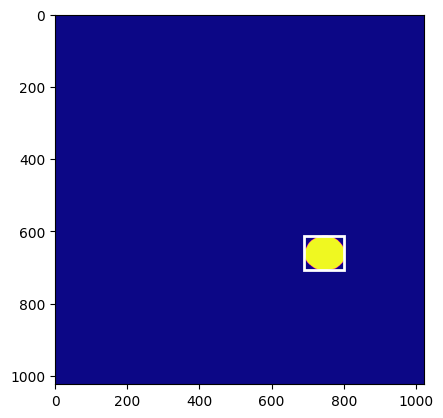

In [6]:
import matplotlib.patches as patches
# assume per_tile_sam2[0]["segmentation"] is a 2D mask (H, W)
# and bbox = [xmin, ymin, xmax, ymax]
mask = per_tile_sam2[0][1]["segmentation"]
bbox = per_tile_sam2[0][1]["bbox"]
xmin, ymin, w, h = bbox

fig, ax = plt.subplots()
ax.imshow(mask, cmap="plasma")

# draw rectangle
rect = patches.Rectangle(
    (xmin, ymin),               # bottom-left corner (x,y)
    w,                # width
    h,                # height
    linewidth=2,
    edgecolor='white',
    facecolor='none'
)
ax.add_patch(rect)

plt.show()

In [20]:
file_path = "/Volumes/warm_SD/data/160/00_series/00/160_00_01_50x.tiff"
image = Image.open(file_path)
was_grayscale = False

if image.mode in ("L", "I"):       # 8-bit or 32-bit grayscale
    was_grayscale = True
    image = image.convert("RGB")   # expand to 3-channel RGB

elif image.mode == "RGBA":         # keep only RGB, drop alpha
    image = image.convert("RGB")

# Convert to NumPy array
image = np.array(image)
tiler = Sam2Tiler(patch_h=1024, patch_w=1024, overlap_h=256, overlap_w=256, merge_iou=0.05)
patches, offsets, padded_shape = tiler.tile_numpy(image)

print(padded_shape)

(2234, 23050, 3)


In [21]:
inst_map, instances = tiler.stitch_sam2_instances(padded_shape[:2],
                                                    offsets[:],
                                                    per_tile_sam2
                                                    )


In [22]:
print(sys.getsizeof(inst_map))
print(len(instances))


205974928
3447


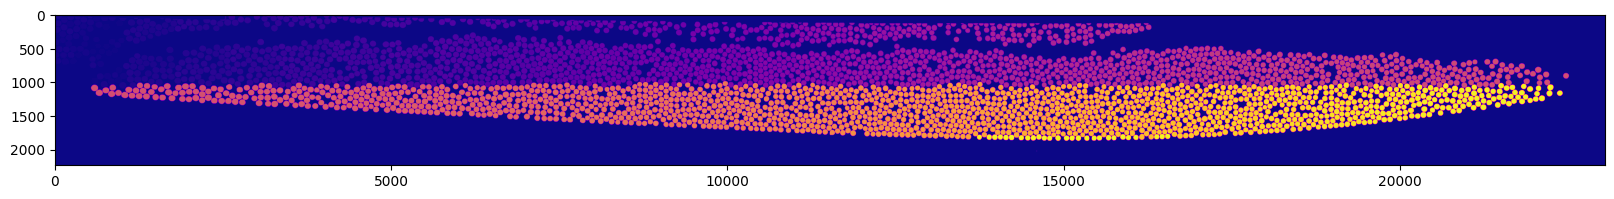

In [23]:
plt.figure(figsize=(20,10))
plt.imshow(inst_map[:,:],cmap="plasma")
plt.show()

In [53]:
from matplotlib import colormaps
import cv2
np.random.seed(3)

def show_anns(anns, borders=True, canvas_shape=None,alpha=0.5):
    """
    Draws annotations on an RGBA canvas.
    
    Each annotation (ann) can have:
      - {'segmentation_crop': (h,w) bool array, 'bbox': [xmin, ymin, width, height]}
      - or {'segmentation': (H,W) bool array}
    
    Args:
        anns: list of dicts
        borders: draw blue outline if True
        canvas_shape: optional (H, W) tuple for global canvas
    """
    if not anns:
        return

    sorted_anns = sorted(anns, key=lambda x: x.get('area', 0), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    # ---- determine canvas size ----
    if canvas_shape is not None:
        H, W = map(int, canvas_shape)
        print(H,W)
    else:
        H = W = 0
        for a in sorted_anns:
            if 'segmentation' in a and isinstance(a['segmentation'], np.ndarray):
                H, W = a['segmentation'].shape
                break
        if H == 0 or W == 0:
            for a in sorted_anns:
                if 'bbox' in a and a['bbox'] is not None:
                    xmin, ymin, w, h = map(int, a['bbox'])
                    H = max(H, ymin + h)
                    W = max(W, xmin + w)

    # RGBA canvas
    img = np.ones((H, W, 4), dtype=float)
    img[..., 3] = 0.0  # transparent background

    cmap = colormaps.get_cmap("plasma")
    num_colors = len(sorted_anns)
    color_indices = np.random.rand(num_colors)

    for i, ann in enumerate(sorted_anns):
        color = cmap(color_indices[i])
        color_mask = np.array([color[0], color[1], color[2], alpha], dtype=float)  # RGBA with alpha

        seg_crop = ann.get('segmentation_crop', None)
        bbox = ann.get('bbox', None)
        seg_full = ann.get('segmentation', None)

        if seg_crop is not None and bbox is not None:
            # bbox in [xmin, ymin, width, height]
            xmin, ymin, w, h = map(int, bbox)
            xmax = xmin + w
            ymax = ymin + h
            m = np.asarray(seg_crop, dtype=bool)

            # clip to canvas
            xmin = max(0, min(W, xmin))
            ymin = max(0, min(H, ymin))
            xmax = max(0, min(W, xmax))
            ymax = max(0, min(H, ymax))
            if xmax <= xmin or ymax <= ymin:
                continue

            subimg = img[ymin:ymax, xmin:xmax]
            mh, mw = m.shape
            sh, sw = subimg.shape[:2]

            # crop mask if it exceeds canvas region
            if (mh, mw) != (sh, sw):
                m = m[:sh, :sw]

            subimg[m] = color_mask

            if borders:
                cnts, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
                for cnt in cnts:
                    if cnt.ndim != 3 or cnt.shape[0] < 2:
                        continue
                    pts = cnt[:, 0, :]
                    xs = pts[:, 0] + xmin
                    ys = pts[:, 1] + ymin
                    ax.plot(xs, ys, linewidth=1.0, color=(0, 0, 1, 0.4))

        elif isinstance(seg_full, np.ndarray) and seg_full.ndim == 2:
            m = seg_full.astype(bool)
            img[m] = color_mask

            if borders:
                cnts, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
                for cnt in cnts:
                    if cnt.ndim != 3 or cnt.shape[0] < 2:
                        continue
                    pts = cnt[:, 0, :]
                    ax.plot(pts[:, 0], pts[:, 1], linewidth=1.0, color=(0, 0, 1, 0.4))

    ax.imshow(img)
    return (img)

2234 23050


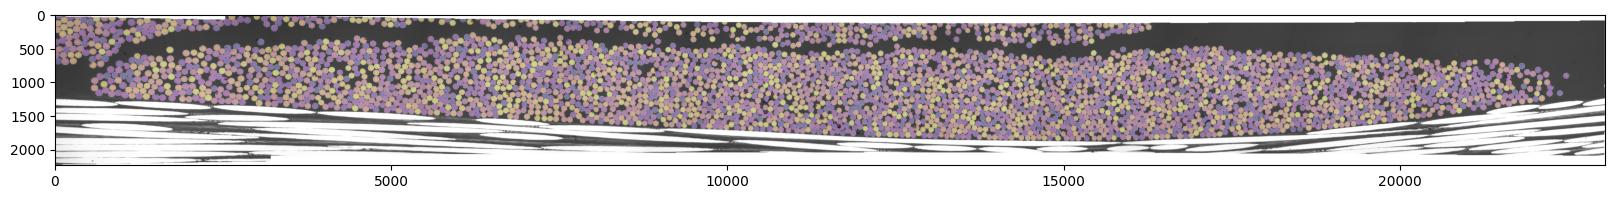

In [59]:


fig, ax = plt.subplots(figsize=(20,10))
ax.imshow(image)
label_image = show_anns(instances, borders=False,alpha=0.35,canvas_shape=image.shape[:2])
fig.canvas.draw()

im = Image.fromarray((label_image * 255).astype(np.uint8), mode='RGBA')
im.save("fig_microscale_analysis_roving_labels.png")

im = Image.fromarray((image).astype(np.uint8), mode='RGB')
im.save("fig_microscale_analysis_roving_original.png")

In [77]:


with h5py.File("160_00_01_50x.h5","w") as F:
    F.create_dataset("image",data=image[:,:,0],compression="gzip")
    F.create_dataset("labels",data=inst_map,compression="gzip")

    group1 = F.create_group("instances")

    for i, (instance) in enumerate(instances):
        subgroup = group1.create_group(f"instance_{i:04d}")
        for key, item in instance.items():
            subgroup.create_dataset(key,data=item)

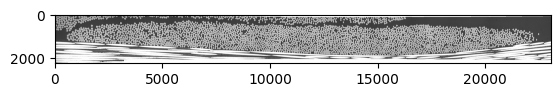

In [67]:
plt.imshow(image)

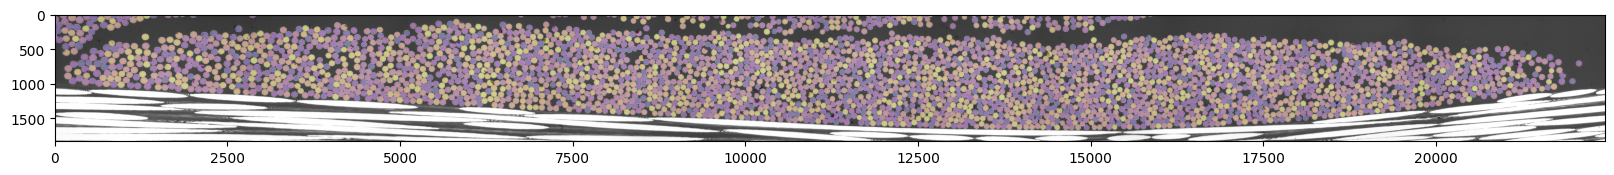

In [60]:
slice_x = slice(200,-200)
slice_y = slice(400,-200)

fig, ax = plt.subplots(figsize=(20,10))
ax.imshow(image[slice_x,slice_y])
ax.imshow(label_image[slice_x,slice_y])

im = Image.fromarray((label_image[slice_x,slice_y] * 255).astype(np.uint8), mode='RGBA')
im.save("fig_microscale_analysis_roving_labels_croped.png")

im = Image.fromarray((image[slice_x,slice_y]).astype(np.uint8), mode='RGB')
im.save("fig_microscale_analysis_roving_original_croped.png")

In [ ]:
np.save()